# 21 cm × Galaxy Cross-Correlation: HERA × Euclid
### Simulating cross-power spectra with 21cmFASTv4 (Davies et al. 2025)

This notebook uses the discrete source model introduced in
[Davies, Mesinger & Murray (2025)](https://arxiv.org/abs/2504.17254) to:

1. Run a **21cmFASTv4** coeval simulation with discrete galaxy sources
2. Apply a **Euclid-like** photometric selection to the galaxy catalogue
3. Compute the **2D cylindrical cross-power spectrum** $P_{21\times\mathrm{gal}}(k_\perp, k_\parallel)$
4. Estimate the **SNR** for a HERA × Euclid cross-correlation detection

---

**Requirements:**
- `21cmFAST >= 4.0.0` — install via `pip install 21cmFAST` (requires C compiler, FFTW3, GSL)
- `numpy`, `matplotlib`, `scipy`, `astropy`

**References:**
- Davies, Mesinger & Murray (2025) — [arXiv:2504.17254](https://arxiv.org/abs/2504.17254) — 21cmFASTv4 discrete source model
- Gagnon-Hartman, Davies & Mesinger (2025) — [arXiv:2502.20447](https://arxiv.org/abs/2502.20447) — galaxy–21cm cross-correlation detection forecasts
- La Plante et al. (2023) — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770) — uncertainty formalism
- Euclid Collaboration (2022) — [arXiv:2108.01201](https://arxiv.org/abs/2108.01201) — Euclid survey specifications

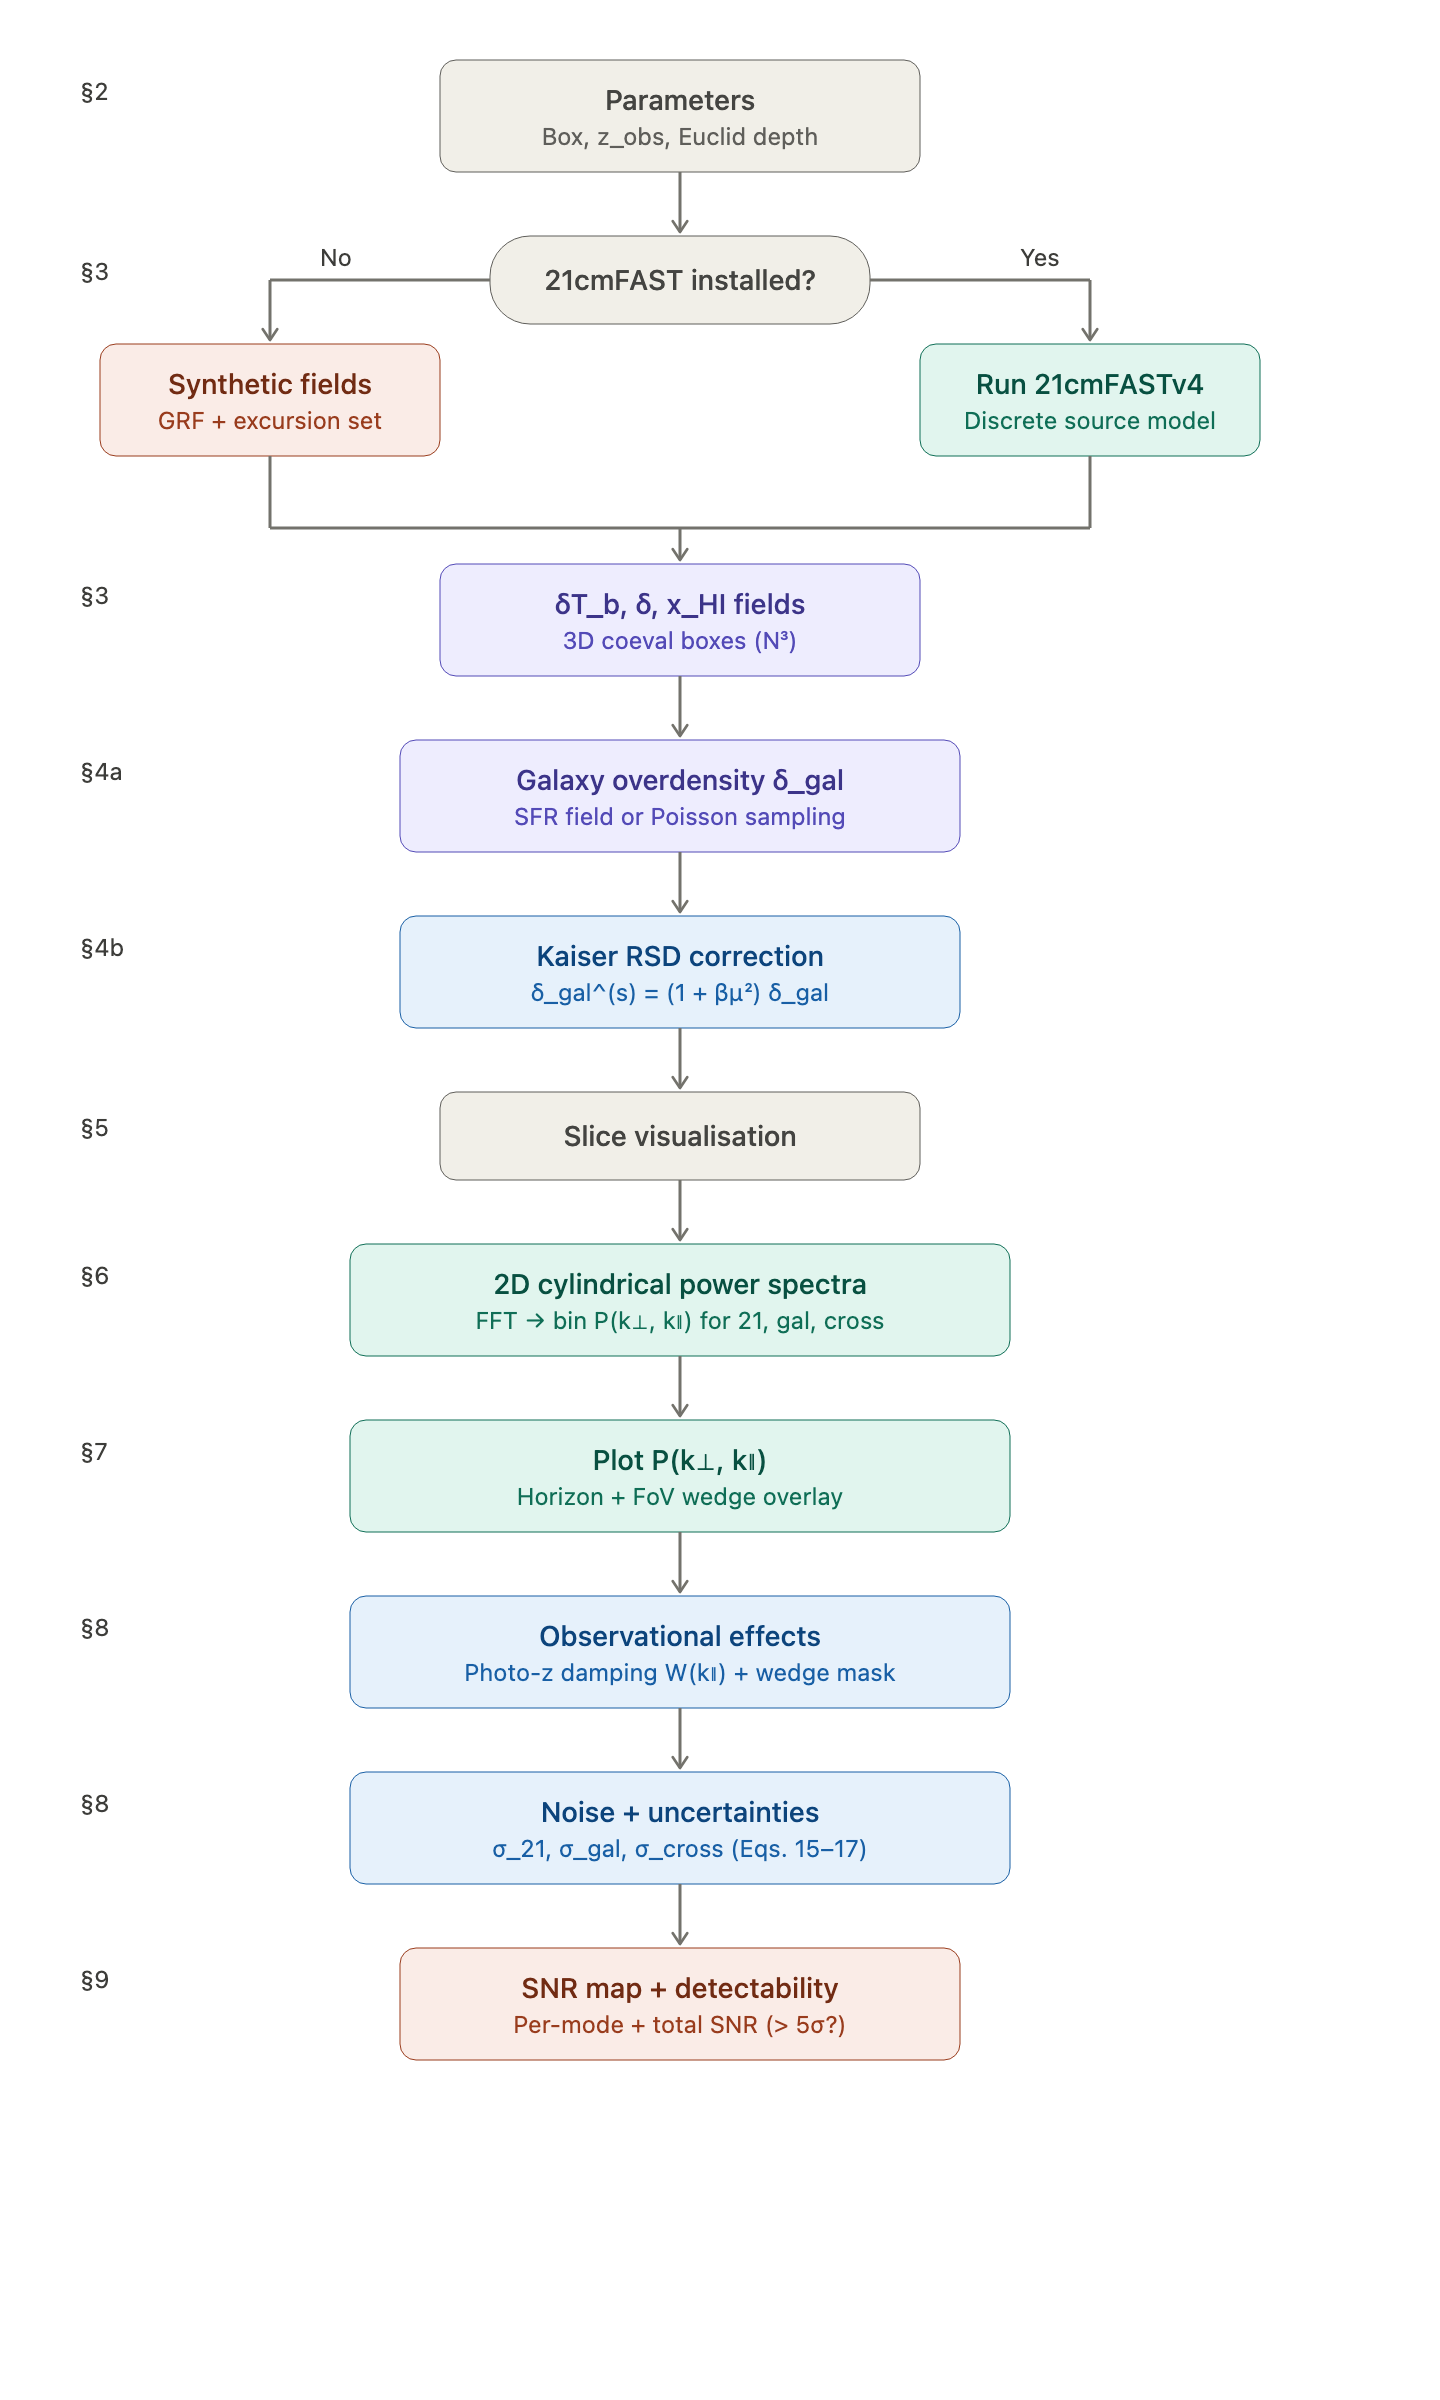

## 1  Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings

warnings.filterwarnings("ignore")

# ── Check whether 21cmFAST is installed ──────────────────────────────────────
try:
    import py21cmfast as p21c
    HAS_21CMFAST = True
    print(f"21cmFAST version: {p21c.__version__}")
except ImportError:
    HAS_21CMFAST = False
    print("21cmFAST not installed — will use synthetic fields for demonstration.")
    print("Install with:  pip install 21cmFAST")

# ── Matplotlib defaults ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":     120,
    "font.size":      12,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "axes.grid":      False,
})

21cmFAST version: 4.1.1


## 2  Simulation parameters

Following Davies et al. (2025), we use the **discrete source model** in 21cmFASTv4.
The key new feature is `USE_HALO_FIELD = True` with the stochastic halo sampler,
which populates dark matter halos with galaxies drawn from empirical scaling relations
(SHMR, SFMS, FMR). This produces a self-consistent galaxy catalogue alongside the
21 cm brightness temperature field.

We use a moderate box size for speed; increase `HII_DIM` and `BOX_LEN` for
publication-quality results (Davies et al. use 1 Gpc boxes with 2 Mpc cells).

In [2]:
# ===========================================================================
#  Simulation configuration
# ===========================================================================
# Increase HII_DIM and BOX_LEN for publication-quality results.
# Davies et al. (2025) use 1 Gpc boxes with 2 Mpc cells.

HII_DIM = 128           # number of cells per side (low-res grid)
BOX_LEN = 256.0         # comoving box side length [Mpc]
DIM     = 3 * HII_DIM   # high-res grid for initial conditions

z_obs   = 6.5           # snapshot redshift (mid-reionization)

# ===========================================================================
#  Euclid-like survey parameters
# ===========================================================================
# Euclid deep fields reach H_AB ~ 26, which at z ~ 8 corresponds
# to a UV absolute magnitude limit of roughly M_UV ~ −18.

M_UV_limit         = -22.66    # UV absolute magnitude cut
photoz_uncertainty = 0.05     # sigma_z for photometric redshifts
mean_galaxy_density = 1e-3    # expected n_gal  [h^3 Mpc^-3]

# ===========================================================================
print(f"Box     : {BOX_LEN:.0f} Mpc,  {HII_DIM}^3 cells  →  cell size = {BOX_LEN / HII_DIM:.1f} Mpc")
print(f"Redshift: z = {z_obs}")
print(f"Euclid  : M_UV < {M_UV_limit},  sigma_z = {photoz_uncertainty}")

Box     : 256 Mpc,  128^3 cells  →  cell size = 2.0 Mpc
Redshift: z = 6.5
Euclid  : M_UV < -22.66,  sigma_z = 0.05


## 3  Run the 21cmFASTv4 simulation

The v4 API uses `InputParameters` to bundle all settings. We use the `"simple"`
template which enables the `CHMF-SAMPLER` discrete source model described in
Davies et al. (2025), Section 2.

The coeval box gives us:
- `brightness_temp` — the 21 cm brightness temperature field $\delta T_b(\mathbf{x})$ [mK]
- `halobox` — per-cell halo/galaxy properties on the HII grid (SFR density, n_ion, …)
- `density` — matter overdensity field $\delta(\mathbf{x})$
- `xH_box` — neutral fraction field $x_{\mathrm{HI}}(\mathbf{x})$

In [3]:
if HAS_21CMFAST:
    print("Running 21cmFAST coeval simulation …")

    inputs = p21c.InputParameters.from_template(
        ["simple"],
        random_seed=42,
    )

    inputs = inputs.clone(
        simulation_options={
            "HII_DIM": HII_DIM,
            "BOX_LEN": BOX_LEN,
            "DIM": DIM,
        },
        matter_options={
            "USE_INTERPOLATION_TABLES": 'hmf-interpolation',
        },
    )

    print(inputs.matter_options)

    coevals = p21c.run_coeval(
        inputs=inputs,
        out_redshifts=[z_obs],
    )

    coeval = coevals[0]

    brightness_temp_field = coeval.brightness_temp
    density_field = coeval.density

    if hasattr(coeval, "xH_box"):
        neutral_fraction = coeval.xH_box
    elif hasattr(coeval, "neutral_fraction"):
        neutral_fraction = coeval.neutral_fraction
    else:
        print(dir(coeval))
        raise AttributeError("Could not find neutral fraction field.")

    print(f"  <x_HI> = {np.mean(neutral_fraction):.3f}")
    print(
        f"  dT_b   : "
        f"[{brightness_temp_field.min():.1f}, "
        f"{brightness_temp_field.max():.1f}] mK"
    )
else:
    # ==================================================================
    #  Generate physically-motivated synthetic fields (fallback)
    # ==================================================================
    # These mock fields reproduce the key statistical features so the
    # rest of the notebook runs without 21cmFAST installed.

    print("Generating synthetic fields (21cmFAST not available) …")
    np.random.seed(42)

    N = HII_DIM
    L = BOX_LEN

    # ── 1. Build a wavenumber grid in Fourier space ──────────────────
    kx = np.fft.fftfreq(N, d=L / N) * 2 * np.pi
    ky = np.fft.fftfreq(N, d=L / N) * 2 * np.pi
    kz = np.fft.fftfreq(N, d=L / N) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    K_magnitude = np.sqrt(KX**2 + KY**2 + KZ**2)
    K_magnitude[0, 0, 0] = 1.0   # avoid division by zero at DC mode

    # ── 2. Matter overdensity from a P(k) ∝ k^−2 random field ───────
    power_spectrum_amplitude = K_magnitude**(-2)
    power_spectrum_amplitude[0, 0, 0] = 0.0   # zero mean

    random_phases = (np.random.standard_normal((N, N, N))
                     + 1j * np.random.standard_normal((N, N, N)))

    density_field_k = np.sqrt(power_spectrum_amplitude / 2) * random_phases
    density_field   = np.fft.ifftn(density_field_k).real
    density_field   = (density_field - density_field.mean()) / density_field.std() * 0.5

    # ── 3. Neutral fraction via inside-out reionization ──────────────
    # Overdense regions ionise first  →  they become 21 cm-dark.
    # We smooth the density on the bubble scale, then threshold.

    target_neutral_fraction = 0.5
    bubble_radius           = 10.0   # Mpc
    k_bubble = 2 * np.pi / bubble_radius

    gaussian_window  = np.exp(-0.5 * K_magnitude**2 / k_bubble**2)
    smoothed_density = np.fft.ifftn(np.fft.fftn(density_field) * gaussian_window).real

    ionisation_threshold = np.percentile(smoothed_density, target_neutral_fraction * 100)
    neutral_fraction     = (smoothed_density < ionisation_threshold).astype(float)

    # ── 4. 21 cm brightness temperature ──────────────────────────────
    # In the saturated spin-temperature limit:  δT_b ≈ T₀ · x_HI · (1 + δ)
    T0_mK = 27.0 * np.sqrt((1 + z_obs) / 10.0)    # mK
    brightness_temp_field = T0_mK * neutral_fraction * (1.0 + density_field)

    print(f"  Box : {N}³ cells, {L:.0f} Mpc")
    print(f"  ⟨x_HI⟩ = {np.mean(neutral_fraction):.3f}")
    print(f"  δT_b   : [{brightness_temp_field.min():.1f}, {brightness_temp_field.max():.1f}] mK")

Running 21cmFAST coeval simulation …
MatterOptions:DEXM_OPTIMIZE               : False
    FILTER                      : spherical-tophat
    HALO_FILTER                 : spherical-tophat
    HMF                         : ST
    KEEP_3D_VELOCITIES          : False
    MINIMIZE_MEMORY             : False
    PERTURB_ALGORITHM           : 2LPT
    PERTURB_ON_HIGH_RES         : False
    POWER_SPECTRUM              : EH
    SAMPLE_METHOD               : MASS-LIMITED
    SMOOTH_EVOLVED_DENSITY_FIELD: False
    SOURCE_MODEL                : CHMF-SAMPLER
    USE_FFTW_WISDOM             : False
    USE_INTERPOLATION_TABLES    : hmf-interpolation
    USE_RELATIVE_VELOCITIES     : False 
  <x_HI> = 0.040
  dT_b   : [0.0, 20.0] mK


## 4  Construct the galaxy density field

### 4a  From the 21cmFASTv4 halo box

21cmFASTv4 produces a `HaloBox` object (`coeval.halobox`) containing per-cell
quantities computed from the CHMF-SAMPLER discrete source model. The key field
is `halo_sfr`: the total star-formation rate density summed over all halos within
each cell. Because UV luminosity scales directly with SFR, this field naturally
up-weights the bright, UV-selected galaxies that Euclid would observe.

> **Note:** The `HaloBox` API exposes gridded (cell-averaged) quantities rather
> than individual halo catalogues. A strict per-halo $M_{\rm UV}$ cut therefore
> requires post-processing the raw halo catalogue output from a lightcone run
> (not demonstrated here). For the cross-correlation statistics shown below the
> SFR-density proxy is an accurate tracer of the bright-galaxy population.

### 4b  Synthetic fallback

If 21cmFAST is not available, we construct a mock galaxy field by
Poisson-sampling a biased density field, which captures the key
statistical property: galaxies preferentially sit in overdense,
**ionised** regions and are therefore **anti-correlated** with the 21 cm
signal on large scales.

In [4]:
cell_volume = (BOX_LEN / HII_DIM) ** 3

if HAS_21CMFAST:
    print("Constructing galaxy density field from 21cmFAST halobox...")

    hb = coeval.halobox
    # In 21cmFASTv4, the HaloBox provides per-cell SFR density (total SFR
    # summed over all halos within each cell). Individual halo positions and
    # UV magnitudes are not exposed via the HaloBox API, so a strict per-halo
    # M_UV cut cannot be applied here. Instead, the SFR density field is used
    # as a galaxy density proxy: it naturally up-weights UV-bright, high-SFR
    # sources that dominate Euclid's observable galaxy population at given z.
    sfr_field = hb.get('halo_sfr')   # shape: (HII_DIM, HII_DIM, HII_DIM)

    mean_sfr = sfr_field.mean()
    if mean_sfr > 0:
        galaxy_overdensity = sfr_field / mean_sfr - 1.0
    else:
        galaxy_overdensity = np.zeros_like(sfr_field)

    print(f"  SFR density  : [{sfr_field.min():.2e}, {sfr_field.max():.2e}] (internal units)")
    print(f"  Galaxy δ     : [{galaxy_overdensity.min():.2f}, {galaxy_overdensity.max():.2f}]")
    # mean_galaxy_density is defined in the survey-parameter block (Sec. 2)
    # and is used only for shot-noise estimation in Sec. 9.
    print(f"  Shot-noise n̄ : {mean_galaxy_density:.2e} h³ Mpc⁻³  (survey parameter)")

else:
    # ==================================================================
    #  Generate physically-motivated synthetic fields (fallback)
    # ==================================================================
    galaxy_bias = 5.0

    expected_counts = (
        mean_galaxy_density
        * cell_volume
        * np.exp(galaxy_bias * density_field)
        * (1.0 - neutral_fraction)
    )

    galaxy_counts = np.random.poisson(np.clip(expected_counts, 0, 50)).astype(float)
    mean_count = galaxy_counts.mean()
    galaxy_overdensity = galaxy_counts / max(mean_count, 1e-10) - 1.0

    print(f"Mean galaxy density : {mean_count / cell_volume:.2e} h³ Mpc⁻³")
    print(f"Total galaxies      : {int(galaxy_counts.sum())}")

Constructing galaxy density field from 21cmFAST halobox...
  SFR density  : [3.48e-17, 1.39e-06] (internal units)
  Galaxy δ     : [-1.00, 1668.37]
  Shot-noise n̄ : 1.00e-03 h³ Mpc⁻³  (survey parameter)


### 4c  Kaiser redshift-space distortion

In redshift space the galaxy overdensity acquires an anisotropic boost
from coherent infall velocities (Kaiser 1987):

$$\delta_{\rm gal}^{(s)}(\mathbf{k}) \;=\;
  \bigl(1 + \beta\,\mu^2\bigr)\;\delta_{\rm gal}(\mathbf{k}),
  \qquad \beta = f/b$$

where $f \approx \Omega_m(z)^{0.55}$ is the linear growth rate,
$b$ is the galaxy bias, and $\mu = k_\parallel / |\mathbf{k}|$.
This enhances power along the line of sight, breaking the isotropy
of the real-space spectrum.

In [20]:
# ======================================================================
#  Kaiser redshift-space distortion  (Kaiser 1987)
# ======================================================================
#  δ_gal^(s)(k) = (1 + β μ²) δ_gal(k)
#
#  where  β = f / b,  f ≈ Ω_m(z)^0.55,  μ = k_∥ / |k|

# ── Growth rate and bias ─────────────────────────────────────────────
OMEGA_M_0 = 0.315
Omega_m_z = OMEGA_M_0 * (1 + z_obs)**3 / (
    OMEGA_M_0 * (1 + z_obs)**3 + (1 - OMEGA_M_0)
)
growth_rate = Omega_m_z ** 0.55          # f(z) — linear approximation
galaxy_bias = 5.0                        # b — typical for high-z LBGs
beta_rsd    = growth_rate / galaxy_bias  # β = f / b

print(f"Ω_m(z={z_obs})  = {Omega_m_z:.4f}")
print(f"Growth rate f  = {growth_rate:.4f}")
print(f"Galaxy bias b  = {galaxy_bias}")
print(f"β = f/b        = {beta_rsd:.4f}")

# ── Apply Kaiser factor in Fourier space ─────────────────────────────
N = HII_DIM
cell_spacing = BOX_LEN / N

kx = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
ky = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
kz = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

k_magnitude = np.sqrt(KX**2 + KY**2 + KZ**2)
k_magnitude[0, 0, 0] = 1.0   # avoid division by zero at DC

# μ = k_∥ / |k|  (LOS along z-axis)
mu = KZ / k_magnitude
mu[0, 0, 0] = 0.0

# Kaiser boost:  (1 + β μ²)
kaiser_factor = 1.0 + beta_rsd * mu**2

# Transform to Fourier space, apply, transform back
galaxy_overdensity_k   = np.fft.fftn(galaxy_overdensity)
galaxy_overdensity_rsd = np.fft.ifftn(galaxy_overdensity_k * kaiser_factor).real

print(f"\nBefore RSD  →  δ_gal std = {galaxy_overdensity.std():.3f}")
print(f"After  RSD  →  δ_gal std = {galaxy_overdensity_rsd.std():.3f}")
print(f"Max Kaiser boost (μ=1)   = {1 + beta_rsd:.3f}×")

# ── Replace the galaxy field with the RSD-corrected version ──────────
galaxy_overdensity = galaxy_overdensity_rsd

Ω_m(z=6.5)  = 0.9949
Growth rate f  = 0.9972
Galaxy bias b  = 5.0
β = f/b        = 0.1994

Before RSD  →  δ_gal std = 5.392
After  RSD  →  δ_gal std = 5.758
Max Kaiser boost (μ=1)   = 1.199×


## 5  Visualise the fields

A slice through the simulation box showing the 21 cm brightness temperature,
the galaxy overdensity, and the neutral fraction. The anti-correlation between
21 cm (bright in neutral regions) and galaxies (concentrated in ionised regions)
should be visually apparent.

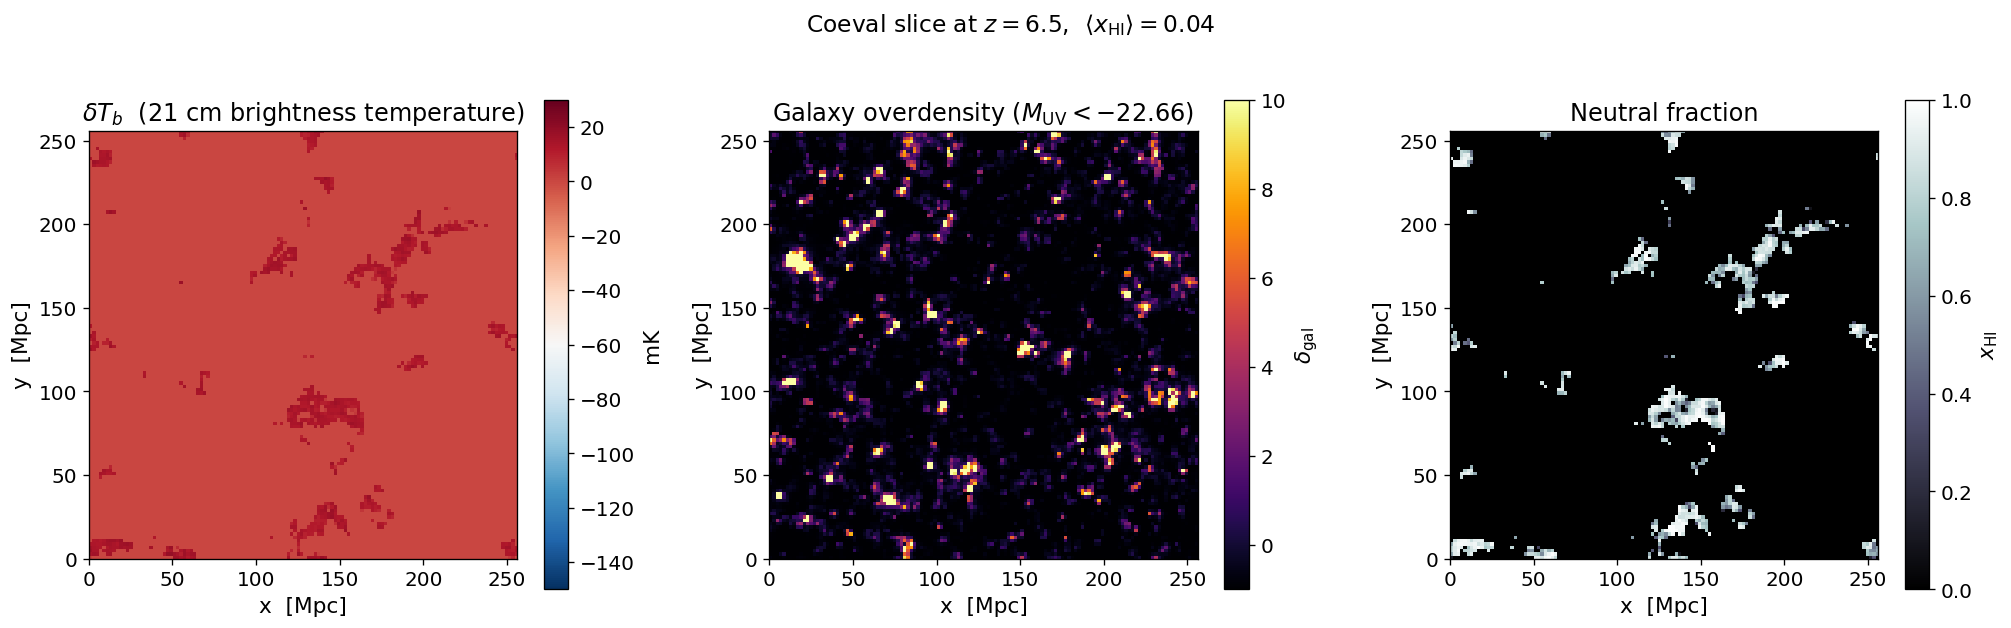

In [21]:
# Take a slice through the middle of the box
slice_index = HII_DIM // 2
spatial_extent = [0, BOX_LEN, 0, BOX_LEN]   # [Mpc]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: 21 cm brightness temperature ────────────────────────────────
image_T21 = axes[0].imshow(
    brightness_temp_field[:, :, slice_index].T,
    origin="lower", extent=spatial_extent,
    cmap="RdBu_r", vmin=-150, vmax=30,
)
fig.colorbar(image_T21, ax=axes[0], label="mK")
axes[0].set_title(r"$\delta T_b$  (21 cm brightness temperature)")

# ── Panel 2: galaxy overdensity ──────────────────────────────────────────
image_gal = axes[1].imshow(
    galaxy_overdensity[:, :, slice_index].T,
    origin="lower", extent=spatial_extent,
    cmap="inferno", vmin=-1, vmax=10,
)
fig.colorbar(image_gal, ax=axes[1], label=r"$\delta_{\rm gal}$")
axes[1].set_title(rf"Galaxy overdensity ($M_{{\rm UV}} < {M_UV_limit}$)")

# ── Panel 3: neutral hydrogen fraction ───────────────────────────────────
image_xH = axes[2].imshow(
    neutral_fraction[:, :, slice_index].T,
    origin="lower", extent=spatial_extent,
    cmap="bone", vmin=0, vmax=1,
)
fig.colorbar(image_xH, ax=axes[2], label=r"$x_{\rm HI}$")
axes[2].set_title("Neutral fraction")

for ax in axes:
    ax.set_xlabel("x  [Mpc]")
    ax.set_ylabel("y  [Mpc]")

mean_xHI = np.mean(neutral_fraction)
plt.suptitle(
    rf"Coeval slice at $z = {z_obs}$,  "
    rf"$\langle x_{{\rm HI}} \rangle = {mean_xHI:.2f}$",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 6  Compute the 2D cylindrical power spectra

We compute three power spectra in cylindrical $(k_\perp, k_\parallel)$ coordinates:

- $P_{21}(k_\perp, k_\parallel)$ — 21 cm auto-power
- $P_{\rm gal}(k_\perp, k_\parallel)$ — galaxy auto-power
- $P_{21 \times \rm gal}(k_\perp, k_\parallel)$ — cross-power (expected to be **negative**
  on large scales due to the anti-correlation)

The cylindrical decomposition matters because:
1. Foreground contamination is confined to a **wedge** in $(k_\perp, k_\parallel)$ space
2. Photo-$z$ errors suppress only the $k_\parallel$ direction
3. The 21 cm signal is anisotropic due to redshift-space distortions

In [22]:
def compute_cylindrical_cross_power(
    field_a,
    field_b,
    box_length,
    n_bins_perp=30,
    n_bins_parallel=30,
):
    """
    Compute the 2D cylindrical cross-power spectrum P(k_perp, k_parallel).

    The line of sight is taken to be the z-axis (axis = 2).

    Parameters
    ----------
    field_a, field_b : ndarray, shape (N, N, N)
        Real-space 3D fields (e.g. brightness temp in mK, galaxy δ).
    box_length : float
        Comoving box side length [Mpc].
    n_bins_perp, n_bins_parallel : int
        Number of bins in k_perp and k_parallel.

    Returns
    -------
    k_perp_centres     : 1D array [Mpc⁻¹]
    k_parallel_centres : 1D array [Mpc⁻¹]
    power_2d           : 2D array, shape (n_bins_perp, n_bins_parallel)
    """
    N = field_a.shape[0]
    volume = box_length ** 3
    cell_spacing = box_length / N
    fundamental_mode = 2 * np.pi / box_length

    # ── Fourier transform both fields ────────────────────────────────
    ft_factor = cell_spacing ** 3
    fourier_a = np.fft.fftn(field_a) * ft_factor
    fourier_b = np.fft.fftn(field_b) * ft_factor

    # ── Cross-power spectrum in 3D ───────────────────────────────────
    power_3d = (fourier_a * np.conj(fourier_b)).real / volume

    # ── Wavenumber grids ─────────────────────────────────────────────
    kx = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
    ky = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
    kz = np.fft.fftfreq(N, d=cell_spacing) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    k_perp_3d     = np.sqrt(KX**2 + KY**2)
    k_parallel_3d = np.abs(KZ)

    # ── Bin edges ────────────────────────────────────────────────────
    # The discrete Fourier modes are linearly spaced at multiples of
    # the fundamental mode Δk = 2π/L.  Pure log-spacing creates empty
    # bins at low k because narrow log-bins fall between the discrete
    # modes.  Fix: start from 0.5 Δk so every discrete mode lands in
    # a bin, and use log-spacing from there.

    k_max_perp = np.sqrt(2) * np.abs(kx).max() * 1.05
    k_max_par  = np.abs(kz).max() * 1.05
    half_dk    = 0.5 * fundamental_mode   # bin edge below the first mode

    k_perp_edges = np.logspace(
        np.log10(half_dk), np.log10(k_max_perp), n_bins_perp + 1
    )
    k_par_edges = np.logspace(
        np.log10(half_dk), np.log10(k_max_par), n_bins_parallel + 1
    )

    # ── Bin the 3D power into 2D ─────────────────────────────────────
    power_2d    = np.zeros((n_bins_perp, n_bins_parallel))
    mode_counts = np.zeros_like(power_2d)

    bin_index_perp = np.digitize(k_perp_3d.ravel(), k_perp_edges) - 1
    bin_index_par  = np.digitize(k_parallel_3d.ravel(), k_par_edges) - 1
    power_flat     = power_3d.ravel()

    inside_bins = (
        (bin_index_perp >= 0) & (bin_index_perp < n_bins_perp) &
        (bin_index_par  >= 0) & (bin_index_par  < n_bins_parallel)
    )
    np.add.at(power_2d,    (bin_index_perp[inside_bins], bin_index_par[inside_bins]), power_flat[inside_bins])
    np.add.at(mode_counts, (bin_index_perp[inside_bins], bin_index_par[inside_bins]), 1)

    # Average power per bin (NaN where no modes fell)
    power_2d = np.divide(
        power_2d, mode_counts,
        where=mode_counts > 0,
        out=np.full_like(power_2d, np.nan),
    )

    # Geometric bin centres
    k_perp_centres = np.sqrt(k_perp_edges[:-1] * k_perp_edges[1:])
    k_par_centres  = np.sqrt(k_par_edges[:-1]  * k_par_edges[1:])

    return k_perp_centres, k_par_centres, power_2d, mode_counts


# ======================================================================
#  Compute all three 2D power spectra
# ======================================================================
T21_fluctuations    = brightness_temp_field - brightness_temp_field.mean()
galaxy_fluctuations = galaxy_overdensity

print("Computing 2D cylindrical power spectra …")

k_perp, k_parallel, P_21cm_auto, mode_counts = compute_cylindrical_cross_power(
    T21_fluctuations, T21_fluctuations, BOX_LEN
)
_, _, P_galaxy_auto, _ = compute_cylindrical_cross_power(
    galaxy_fluctuations, galaxy_fluctuations, BOX_LEN
)
_, _, P_cross, _ = compute_cylindrical_cross_power(
    T21_fluctuations, galaxy_fluctuations, BOX_LEN
)

large_scale_mean = np.nanmean(P_cross[:5, :5])
n_empty = np.sum(mode_counts == 0)
print(f"\nk_perp     range : [{k_perp.min():.4f},  {k_perp.max():.3f}] Mpc⁻¹")
print(f"k_parallel range : [{k_parallel.min():.4f},  {k_parallel.max():.3f}] Mpc⁻¹")
print(f"Empty bins       : {n_empty} / {mode_counts.size}")
print(f"Large-scale cross-spectrum sign: {'NEGATIVE (anti-correlated) ✓' if large_scale_mean < 0 else 'POSITIVE'}")

Computing 2D cylindrical power spectra …

k_perp     range : [0.0134,  2.137] Mpc⁻¹
k_parallel range : [0.0133,  1.520] Mpc⁻¹
Empty bins       : 400 / 900
Large-scale cross-spectrum sign: NEGATIVE (anti-correlated) ✓


## 7  Plot the 2D cylindrical power spectra

Three panels show $P_{21}$, $P_{\rm gal}$, and the signed cross-power
$P_{21\times\rm gal}$ in $(k_\perp,\, k_\parallel)$ space.

**NaN handling.**  The logarithmic binning in the previous cell can leave
isolated bins empty (no discrete Fourier modes fall inside a very narrow
log-bin).  For display purposes only, these NaN pixels are filled by
iterative 3×3 nearest-neighbour averaging (`fill_nan_nearest`); the
underlying power spectrum arrays are not modified.

**Foreground wedge and horizon line.**  Spectrally smooth foregrounds
contaminate a wedge-shaped region of $(k_\perp,\, k_\parallel)$ space.
Following Thyagarajan et al. (2015) and La Plante et al. (2023, Eq. 10),
the slope of the horizon wedge is

$$m(z) \;\equiv\; \frac{k_\parallel}{k_\perp}
      \;=\; \frac{\lambda(z)\, D_c(z)\, f_{21}\, H(z)}
                  {c^2\, (1+z)^2}$$

where $\lambda(z) = c\,(1+z)/f_{21}$ is the observed wavelength,
$D_c(z)$ is the comoving distance, $f_{21} = 1420\;\mathrm{MHz}$ is
the 21 cm rest frequency, and $H(z)$ is the Hubble parameter.  This
represents maximal foreground contamination extending to the horizon.

The narrower **primary-beam (field-of-view) wedge** replaces the
horizon angle with the HERA dish half-angle
$\theta_0 \approx \lambda / D$, giving
$m_{\rm FoV} = \sin(\theta_0)\, m(z)$.

Both lines are overlaid on each panel: the horizon line (solid) and the
primary-beam wedge (dashed).

**Signed log scale.**  The cross-power spectrum changes sign (negative
where 21 cm and galaxies are anti-correlated, positive otherwise), so
panel 3 uses sign$(P) \times \log_{10}|P|$: blue is negative (the
expected large-scale anti-correlation), red is positive.

Observed wavelength  : λ = 1.584 m
Comoving distance    : D_c = 8638 Mpc
Horizon wedge slope  : m = 2.989
HERA beam half-angle : θ = 6.5°
HERA FoV wedge slope      : m_FoV = 0.337


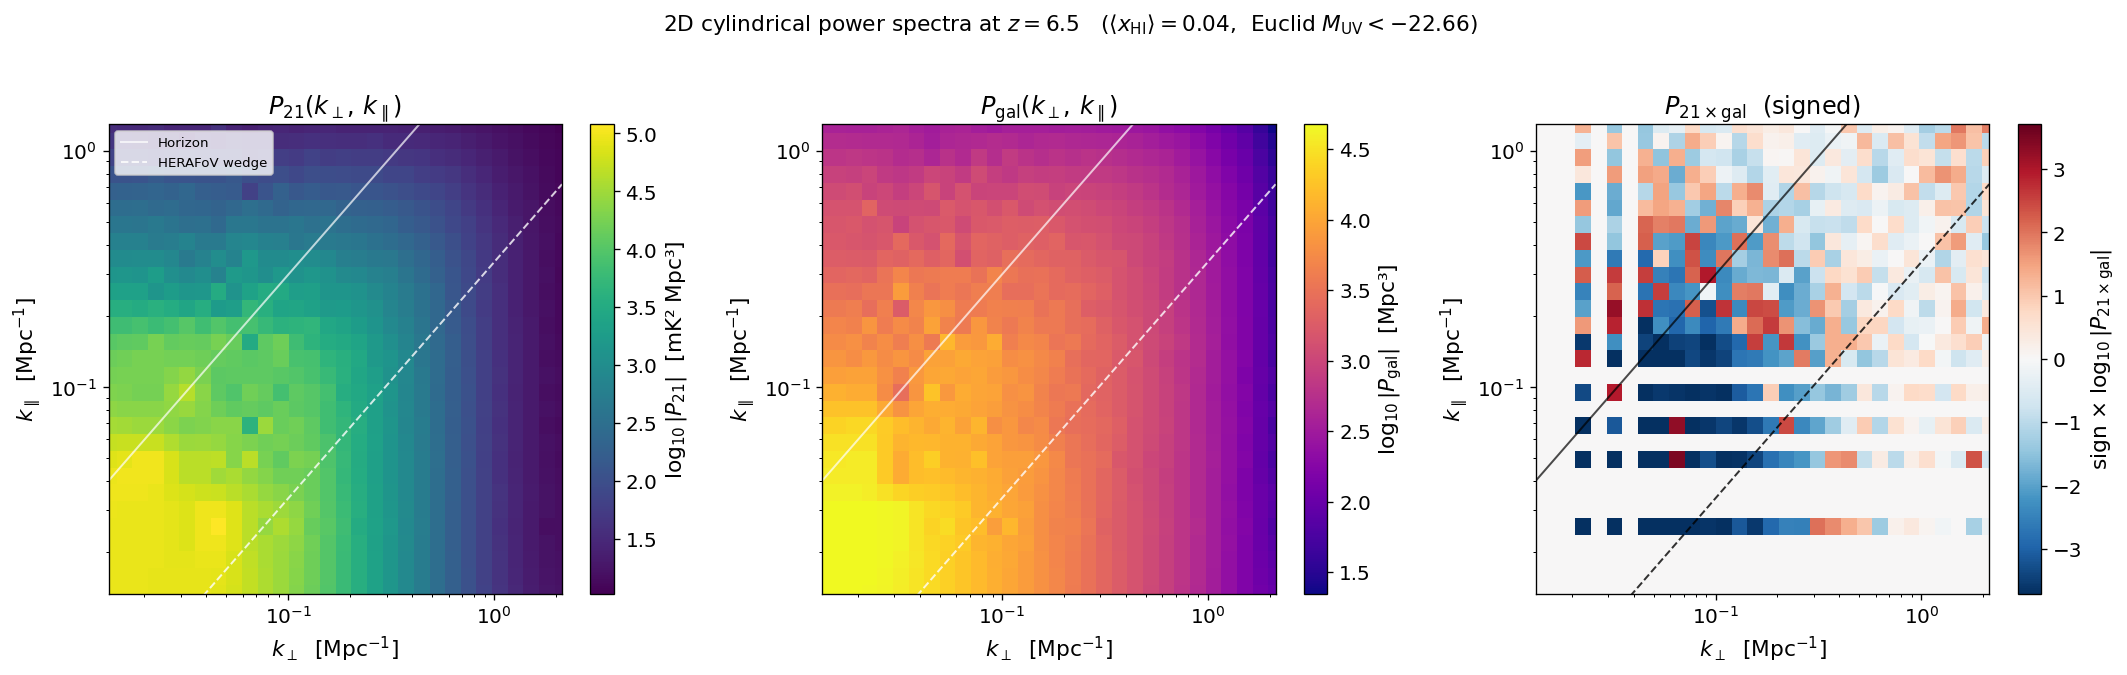

In [23]:
from scipy.ndimage import generic_filter


def fill_nan_nearest(arr):
    """Replace NaN pixels with the nearest non-NaN neighbour (for display only)."""
    mask = np.isnan(arr)
    if not mask.any():
        return arr
    filled = arr.copy()
    for _ in range(max(arr.shape)):
        if not np.isnan(filled).any():
            break
        kernel_filled = generic_filter(
            filled, np.nanmean, size=3, mode="nearest"
        )
        filled = np.where(np.isnan(filled), kernel_filled, filled)
    return filled


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))


# ======================================================================
#  Foreground wedge geometry (Thyagarajan+2015; La Plante+2023, Eq. 10)
# ======================================================================
#
#           λ(z) · D_c(z) · f_21 · H(z)
#   m(z) = ──────────────────────────────
#                c² · (1 + z)²
#
# This is the HORIZON wedge slope — maximal foreground contamination.

SPEED_OF_LIGHT_KMS = 3e5                           # c   [km s⁻¹]
SPEED_OF_LIGHT_MPS = 3e8                           # c   [m s⁻¹]
HUBBLE_CONSTANT    = 67.36                         # H₀  [km s⁻¹ Mpc⁻¹]
OMEGA_MATTER       = 0.315
F_21_MHZ           = 1420.405                      # 21 cm rest frequency [MHz]
F_21_HZ            = F_21_MHZ * 1e6                # [Hz]
HERA_DISH_DIAMETER = 14.0                          # [m]


def hubble_parameter(z):
    """H(z) for flat ΛCDM [km s⁻¹ Mpc⁻¹]."""
    return HUBBLE_CONSTANT * np.sqrt(OMEGA_MATTER * (1 + z)**3 + (1 - OMEGA_MATTER))


# Comoving distance to z_obs
Hz_obs = hubble_parameter(z_obs)
comoving_distance, _ = quad(
    lambda z_: SPEED_OF_LIGHT_KMS / hubble_parameter(z_),
    0, z_obs,
)   # D_c [Mpc]

# Observed wavelength
lambda_obs = SPEED_OF_LIGHT_MPS * (1 + z_obs) / F_21_HZ   # [m]

# ── Horizon wedge slope (Eq. 10) ─────────────────────────────────────
# m(z) = λ(z) · D_c(z) · f_21 · H(z) / (c² · (1+z)²)
# Using consistent units:  λ [m], D_c [Mpc], f_21 [Hz], H [km/s/Mpc], c [m/s]
# The Mpc and km/s cancel when the ratio is dimensionless.
horizon_slope = (
    lambda_obs * comoving_distance * F_21_HZ * Hz_obs
    / (SPEED_OF_LIGHT_MPS * SPEED_OF_LIGHT_KMS * (1 + z_obs)**2)
)

# ── Primary-beam (FoV) wedge slope ───────────────────────────────────
# The HERA primary beam half-angle: θ_0 ≈ λ / D
theta_fov       = lambda_obs / HERA_DISH_DIAMETER              # [rad]
fov_wedge_slope = np.sin(theta_fov) * horizon_slope

# ── Build the two lines on the k_perp axis ───────────────────────────
k_perp_line   = np.logspace(np.log10(k_perp.min()), np.log10(k_perp.max()), 200)
k_par_horizon = k_perp_line * horizon_slope
k_par_fov     = k_perp_line * fov_wedge_slope

print(f"Observed wavelength  : λ = {lambda_obs:.3f} m")
print(f"Comoving distance    : D_c = {comoving_distance:.0f} Mpc")
print(f"Horizon wedge slope  : m = {horizon_slope:.3f}")
print(f"HERA beam half-angle : θ = {np.degrees(theta_fov):.1f}°")
print(f"HERA FoV wedge slope      : m_FoV = {fov_wedge_slope:.3f}")


# ── Panel 1: 21 cm auto-power ───────────────────────────────────────
P21_display = fill_nan_nearest(np.log10(np.abs(P_21cm_auto.T)))
image_0 = axes[0].pcolormesh(
    k_perp, k_parallel, P21_display,
    cmap="viridis", shading="auto",
)
fig.colorbar(image_0, ax=axes[0], label=r"$\log_{10} |P_{21}|$  [mK² Mpc³]")
axes[0].plot(k_perp_line, k_par_horizon, "w-",  lw=1.2, alpha=0.7, label="Horizon")
axes[0].plot(k_perp_line, k_par_fov,     "w--", lw=1.2, alpha=0.8, label="HERAFoV wedge")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_title(r"$P_{21}(k_\perp,\, k_\parallel)$")

# ── Panel 2: galaxy auto-power ──────────────────────────────────────
Pgal_display = fill_nan_nearest(np.log10(np.abs(P_galaxy_auto.T)))
image_1 = axes[1].pcolormesh(
    k_perp, k_parallel, Pgal_display,
    cmap="plasma", shading="auto",
)
fig.colorbar(image_1, ax=axes[1], label=r"$\log_{10} |P_{\rm gal}|$  [Mpc³]")
axes[1].plot(k_perp_line, k_par_horizon, "w-",  lw=1.2, alpha=0.7)
axes[1].plot(k_perp_line, k_par_fov,     "w--", lw=1.2, alpha=0.8)
axes[1].set_title(r"$P_{\rm gal}(k_\perp,\, k_\parallel)$")

# ── Panel 3: cross-power (signed) ───────────────────────────────────
cross_amplitude = np.abs(P_cross.T)
cross_sign      = np.sign(P_cross.T)
signed_log_raw  = np.where(
    cross_amplitude > 0,
    np.log10(cross_amplitude) * cross_sign,
    0.0,
)
signed_log_cross = fill_nan_nearest(signed_log_raw)
colour_limit     = np.nanpercentile(np.abs(signed_log_cross[signed_log_cross != 0]), 95)

image_2 = axes[2].pcolormesh(
    k_perp, k_parallel, signed_log_cross,
    cmap="RdBu_r", shading="auto",
    vmin=-colour_limit, vmax=colour_limit,
)
fig.colorbar(image_2, ax=axes[2],
             label=r"sign $\times$ $\log_{10} |P_{21 \times \rm gal}|$")
axes[2].plot(k_perp_line, k_par_horizon, "k-",  lw=1.2, alpha=0.7)
axes[2].plot(k_perp_line, k_par_fov,     "k--", lw=1.2, alpha=0.8)
axes[2].set_title(r"$P_{21 \times \rm gal}$  (signed)")

# ── Shared formatting ───────────────────────────────────────────────
mean_xHI = np.mean(neutral_fraction)
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [Mpc$^{-1}$]")
    ax.set_xlim(k_perp[0], k_perp[-1])
    ax.set_ylim(k_parallel[0], k_parallel[-2])

plt.suptitle(
    rf"2D cylindrical power spectra at $z = {z_obs}$   "
    rf"($\langle x_{{\rm HI}} \rangle = {mean_xHI:.2f}$,  "
    rf"Euclid $M_{{\rm UV}} < {M_UV_limit}$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

## 8  Apply photo-$z$ damping and foreground wedge

Two observational effects shape the measurable signal in $(k_\perp, k_\parallel)$ space:

1. **Photo-$z$ damping** — Euclid's photometric redshift uncertainty
   $\sigma_z \approx 0.05$ smears the LOS, suppressing $P_{\rm gal}$ by $W^2$
   and $P_{21 \times \rm gal}$ by $W$ at high $k_\parallel$.

2. **Foreground wedge** — spectrally smooth foregrounds occupy the region
   $k_\parallel < k_\perp \cdot \chi \cdot H(z) / [c(1+z)]$, which must be
   excised from the 21 cm analysis.

In [24]:
# ======================================================================
#  Cosmological parameters (Planck 2018)
# ======================================================================
SPEED_OF_LIGHT_KMS = 3e5      # c  [km s⁻¹]
HUBBLE_CONSTANT    = 67.36    # H₀ [km s⁻¹ Mpc⁻¹]
OMEGA_MATTER       = 0.315    # Ωₘ
OMEGA_LAMBDA       = 1.0 - OMEGA_MATTER


def hubble_parameter(z):
    """H(z) for flat ΛCDM  [km s⁻¹ Mpc⁻¹]."""
    return HUBBLE_CONSTANT * np.sqrt(OMEGA_MATTER * (1 + z)**3 + OMEGA_LAMBDA)


# ======================================================================
#  Photo-z damping kernel W(k_parallel)
# ======================================================================
# A photometric redshift error σ_z smears the radial position of each
# galaxy by σ_r = c σ_z / H(z).  In Fourier space this suppresses modes
# along the LOS as  W(k_∥) = exp(−½ k_∥² σ_r²).
#
# The cross-spectrum is damped by ONE factor of W (only the galaxy side
# is smeared), while the galaxy auto is damped by W² (both sides smeared).

Hz_obs           = hubble_parameter(z_obs)
radial_smearing  = SPEED_OF_LIGHT_KMS * photoz_uncertainty / Hz_obs   # σ_r [Mpc]

# Broadcast k_parallel to match the 2D power spectrum shape
K_PAR_BROADCAST = k_parallel[np.newaxis, :]   # shape (1, n_bins_par)
photoz_kernel   = np.exp(-0.5 * K_PAR_BROADCAST**2 * radial_smearing**2)

# Apply damping to the observed spectra
P_cross_observed  = P_cross       * photoz_kernel       # one factor of W
P_galaxy_observed = P_galaxy_auto * photoz_kernel**2     # two factors of W
# (P_21cm is unchanged — radio interferometry has precise frequency/redshift)


# ======================================================================
#  Foreground wedge mask
# ======================================================================
# Spectrally smooth foregrounds contaminate modes satisfying
#   k_∥ < k_⊥ · χ(z) · H(z) / [c (1+z)]
# where χ(z) is the comoving distance.  We add a small buffer.

comoving_distance, _ = quad(
    lambda z_prime: SPEED_OF_LIGHT_KMS / hubble_parameter(z_prime),
    0, z_obs,
)   # [Mpc]

wedge_slope  = comoving_distance * Hz_obs / (SPEED_OF_LIGHT_KMS * (1 + z_obs))
wedge_buffer = 0.02   # Mpc⁻¹ safety margin beyond the horizon line

K_PERP_GRID, K_PAR_GRID = np.meshgrid(k_perp, k_parallel, indexing="ij")
outside_wedge = K_PAR_GRID > (K_PERP_GRID * wedge_slope + wedge_buffer)

print(f"Photo-z smearing : σ_r = {radial_smearing:.1f} Mpc")
print(f"Wedge slope      : {wedge_slope:.3f}")
print(f"Modes outside wedge : {outside_wedge.sum() / outside_wedge.size:.1%}")

Photo-z smearing : σ_r = 19.3 Mpc
Wedge slope      : 2.989
Modes outside wedge : 26.2%


## 9  Cross-correlation SNR map

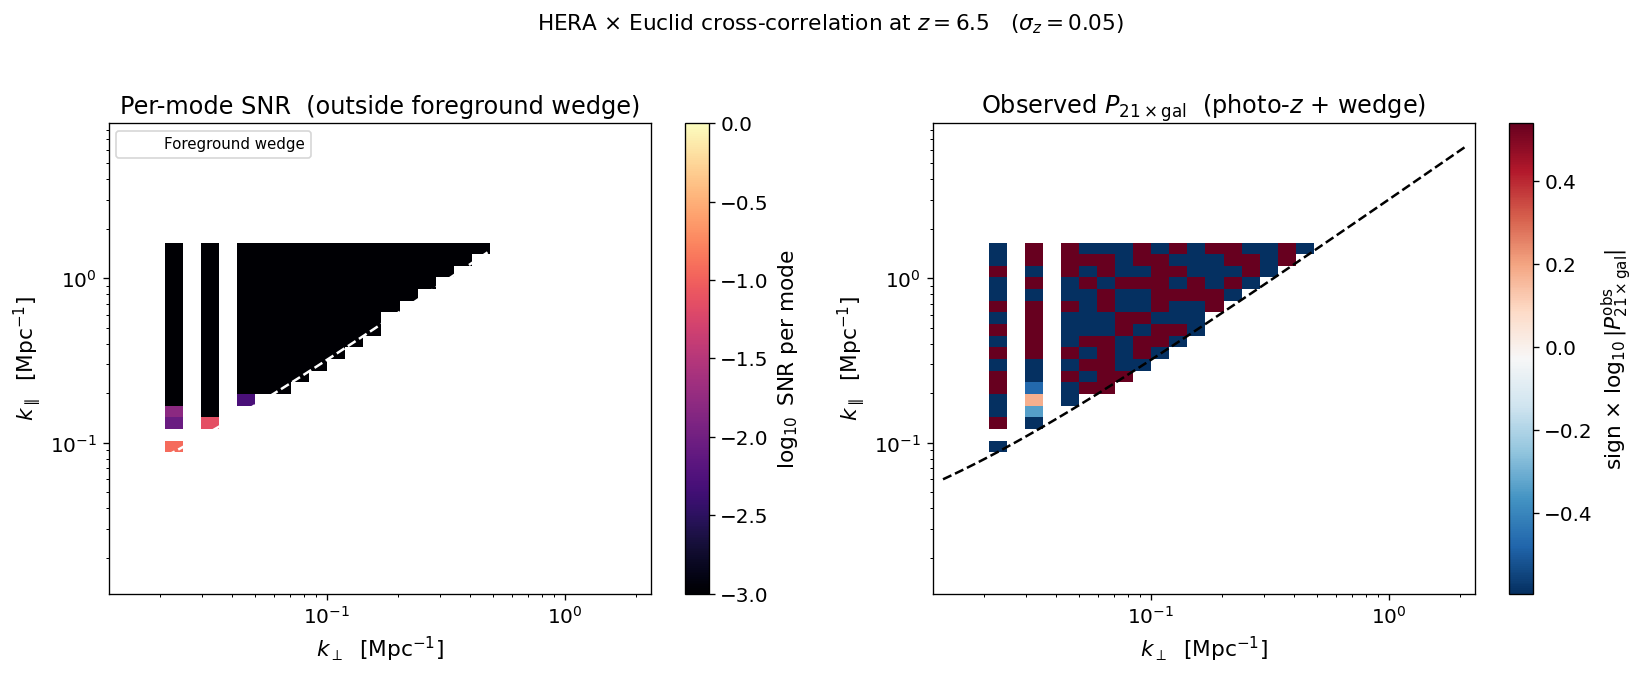


Total cross-correlation SNR (outside wedge): 0.1 σ
Detection (> 5σ) ?  NO


In [26]:
# ======================================================================
#  Noise power spectra
# ======================================================================

# ── 21 cm thermal noise (simplified HERA-like estimate) ──────────────
# For a proper calculation, replace with 21cmSense (Pober+2014).
observed_frequency = 1.42e9 / (1 + z_obs)                      # Hz
system_temperature = (100 + 60 * (300e6 / observed_frequency)**2.55) * 1e3  # mK
integration_time   = 1000 * 3600                                # 1000 hours → seconds
bandwidth          = 8e6                                        # 8 MHz → Hz

P_noise_21cm = (
    system_temperature**2 * 1e3 / (integration_time * bandwidth)
    * np.ones_like(P_cross)
)

# ── Galaxy shot noise ────────────────────────────────────────────────
#   P_shot = 1 / n̄_gal
P_noise_galaxy = 1.0 / mean_galaxy_density


# ======================================================================
#  Per-mode uncertainty (La Plante et al. 2023, Eqs. 15–17)
# ======================================================================

# Eq. 16 — 21 cm auto uncertainty
sigma_21cm = np.abs(P_21cm_auto) + P_noise_21cm

# Eq. 17 — galaxy auto uncertainty (using photo-z–damped spectrum)
sigma_galaxy = np.abs(P_galaxy_observed) + P_noise_galaxy

# Eq. 15 — cross-spectrum uncertainty
sigma_cross = np.sqrt(
    0.5 * (P_cross_observed**2 + sigma_21cm * sigma_galaxy)
)


# ======================================================================
#  Signal-to-noise ratio
# ======================================================================
SNR_per_mode = np.abs(P_cross_observed) / sigma_cross

# Mask the foreground wedge (set contaminated modes to NaN)
SNR_outside_wedge = np.where(outside_wedge, SNR_per_mode, np.nan)


# ======================================================================
#  Plot
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel 1: per-mode SNR map ────────────────────────────────────────
image_snr = axes[0].pcolormesh(
    k_perp, k_parallel,
    np.log10(SNR_outside_wedge.T),
    cmap="magma", shading="auto", vmin=-3, vmax=0,
)
fig.colorbar(image_snr, ax=axes[0], label=r"$\log_{10}$ SNR per mode")

# Draw the foreground wedge boundary
k_perp_line = np.logspace(np.log10(k_perp.min()), np.log10(k_perp.max()), 100)
k_par_wedge_line = k_perp_line * wedge_slope + wedge_buffer
axes[0].plot(k_perp_line, k_par_wedge_line, "w--", lw=1.5, label="Foreground wedge")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("Per-mode SNR  (outside foreground wedge)")

# ── Panel 2: observed cross-power with photo-z + wedge ───────────────
P_cross_display     = np.where(outside_wedge, P_cross_observed, np.nan)
display_amplitude   = np.abs(P_cross_display.T)
display_sign        = np.sign(P_cross_display.T)
display_colour_lim  = np.nanpercentile(
    np.log10(display_amplitude[display_amplitude > 0]), 95
)
signed_display = np.log10(display_amplitude) * display_sign

image_cross = axes[1].pcolormesh(
    k_perp, k_parallel, signed_display,
    cmap="RdBu_r", shading="auto",
    vmin=-display_colour_lim, vmax=display_colour_lim,
)
fig.colorbar(
    image_cross, ax=axes[1],
    label=r"sign $\times$ $\log_{10}|P_{21 \times \rm gal}^{\rm obs}|$",
)
axes[1].plot(k_perp_line, k_par_wedge_line, "k--", lw=1.5)
axes[1].set_title(r"Observed $P_{21 \times \rm gal}$  (photo-$z$ + wedge)")

# ── Shared formatting ────────────────────────────────────────────────
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [Mpc$^{-1}$]")

plt.suptitle(
    rf"HERA $\times$ Euclid cross-correlation at $z = {z_obs}$   "
    rf"($\sigma_z = {photoz_uncertainty}$)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Total detection significance ─────────────────────────────────────
valid_snr = SNR_per_mode[outside_wedge]
total_snr = np.sqrt(np.nansum(valid_snr**2))

print(f"\nTotal cross-correlation SNR (outside wedge): {total_snr:.1f} σ")
print(f"Detection (> 5σ) ?  {'YES' if total_snr > 5 else 'NO'}")

## 10  Summary

This notebook demonstrates the end-to-end workflow for simulating a
HERA × Euclid 21 cm–galaxy cross-correlation using 21cmFASTv4:

1. **21cmFASTv4** generates self-consistent 21 cm and galaxy fields
   via the discrete source model (Davies et al. 2025)
2. A **Euclid-like** magnitude cut selects observable galaxies
3. The **2D cross-power spectrum** $P_{21 \times \rm gal}(k_\perp, k_\parallel)$
   is computed and shows the expected large-scale anti-correlation
4. **Photo-$z$ damping** and **foreground wedge** excision are applied
5. The **SNR map** identifies which Fourier modes drive the detection

### To improve this for publication

- Use larger boxes (1 Gpc, 2 Mpc cells) as in Davies et al. (2025)
- Replace the simplified noise model with [21cmSense](https://github.com/jpober/21cmSense)
- Run full lightcones instead of coeval snapshots
- Include redshift-space distortions
- Sweep over $\sigma_z$ and magnitude limits to optimise survey design
- Add mode counting for proper total SNR estimation

### References

- Davies, Mesinger & Murray (2025) — [arXiv:2504.17254](https://arxiv.org/abs/2504.17254)
- Gagnon-Hartman, Davies & Mesinger (2025) — [arXiv:2502.20447](https://arxiv.org/abs/2502.20447)
- La Plante et al. (2023) — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770)
- Mesinger, Furlanetto & Cen (2011) — [arXiv:1003.3878](https://arxiv.org/abs/1003.3878)
- Murray, Greig & Mesinger (2020) — [JOSS 5(54)](https://doi.org/10.21105/joss.02582)
- Lidz et al. (2009) — [arXiv:0806.1055](https://arxiv.org/abs/0806.1055)